# Hourly Energy Consumption Analysis

This notebook analyzes energy usage patterns based on hourly consumption trends.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/energy_data.csv")
df.head()

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,85,0,36,0,121
1,2023-01-01 01:00:00,0,0,73,1023,1096
2,2023-01-01 02:00:00,0,0,43,0,43
3,2023-01-01 03:00:00,167,0,22,840,1029
4,2023-01-01 04:00:00,116,1881,50,0,2047


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

In [4]:
df['hour'] = df.index.hour
df.head()

,fridge,ac,lights,microwave,total_power,hour
timestamp,,,,,,
2023-01-01 00:00:00,85,0,36,0,121,0
2023-01-01 01:00:00,0,0,73,1023,1096,1
2023-01-01 02:00:00,0,0,43,0,43,2
2023-01-01 03:00:00,167,0,22,840,1029,3
2023-01-01 04:00:00,116,1881,50,0,2047,4


In [5]:
hourly_avg = df.groupby('hour')['total_power'].mean()
hourly_avg

hour
0      976.386740
1     1037.550000
2     1058.105556
3     1067.433333
4     1007.311111
5     1014.416667
6     1007.950000
7      881.983333
8      964.466667
9      912.327778
10     894.422222
11     964.627778
12    1045.916667
13     963.338889
14     857.055556
15     963.144444
16     973.266667
17     963.950000
18    1108.455556
19    1007.727778
20    1040.333333
21    1044.622222
22     905.238889
23    1135.955556
Name: total_power, dtype: float64

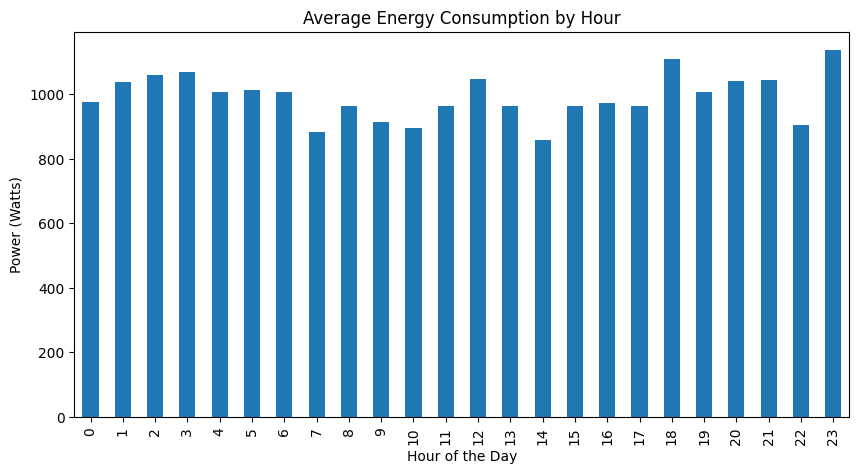

In [6]:
plt.figure(figsize=(10,5))

hourly_avg.plot(kind='bar')

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Power (Watts)")

plt.show()

## Observation

Energy consumption varies across different hours of the day.
Higher usage is observed during peak hours, indicating increased appliance activity.
This helps identify high energy consumption periods.

In [7]:
peak_hour = hourly_avg.idxmax()
print("Peak Energy Usage Hour:", peak_hour)

Peak Energy Usage Hour: 23
